<a href="https://colab.research.google.com/github/Jessica1842553/MCDpycd2026/blob/main/Tarea7_PCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Procesamiento de audio

Jessica Lizeth Hernández Bracho - 1842553

In [1]:
!pip install hub av "deeplake<4" pywavelets dtw-python soundfile --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 643.4/643.4 kB 12.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.9/808.9 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 13.3 MB/s eta

In [2]:
import hub
import numpy as np
import IPython.display as ipd
import matplotlib.pyplot as plt
import pywt
from dtw import dtw

/usr/local/lib/python3.12/dist-packages/deeplake/util/check_latest_version.py:32: UserWarning: A newer version of deeplake (4.7.0) is available. It's recommended that you update to the latest version using `pip install -U deeplake`.
  warnings.warn(


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



- Descarga de dataset

In [3]:
# 1. Cargar el dataset Spoken MNIST
ds = hub.load("hub://activeloop/spoken_mnist")

# 2. Muestra A: Un '0'
audio_A = ds[0]['audio'].numpy()[:, 0]
metadata_A = ds[0]['labels'].data()
print(f"MUESTRA A -> Dígito: '{metadata_A['text'][0]}'")
ipd.display(ipd.Audio(audio_A, rate=8000))

# 3. Muestra B: Un '1'
audio_B = ds[501]['audio'].numpy()[:, 0]
metadata_B = ds[501]['labels'].data()
print(f"\nMUESTRA B -> Dígito: '{metadata_B['text'][0]}'")
ipd.display(ipd.Audio(audio_B, rate=8000))

# 4. Muestra Incógnita: Otro '0'
audio_test = ds[1]['audio'].numpy()[:, 0]
metadata_test = ds[1]['labels'].data()
print(f"\nMUESTRA INCÓGNITA -> Dígito Real: '{metadata_test['text'][0]}'")
ipd.display(ipd.Audio(audio_test, rate=8000))

-

Opening dataset in read-only mode as you don't have write permissions.


|

This dataset can be visualized in Jupyter Notebook by ds.visualize() or at https://app.activeloop.ai/activeloop/spoken_mnist



/

hub://activeloop/spoken_mnist loaded successfully.



MUESTRA A -> Dígito: '0'



MUESTRA B -> Dígito: '1'



MUESTRA INCÓGNITA -> Dígito Real: '0'


- Visualización de las Formas de Onda (Dominio del Tiempo)

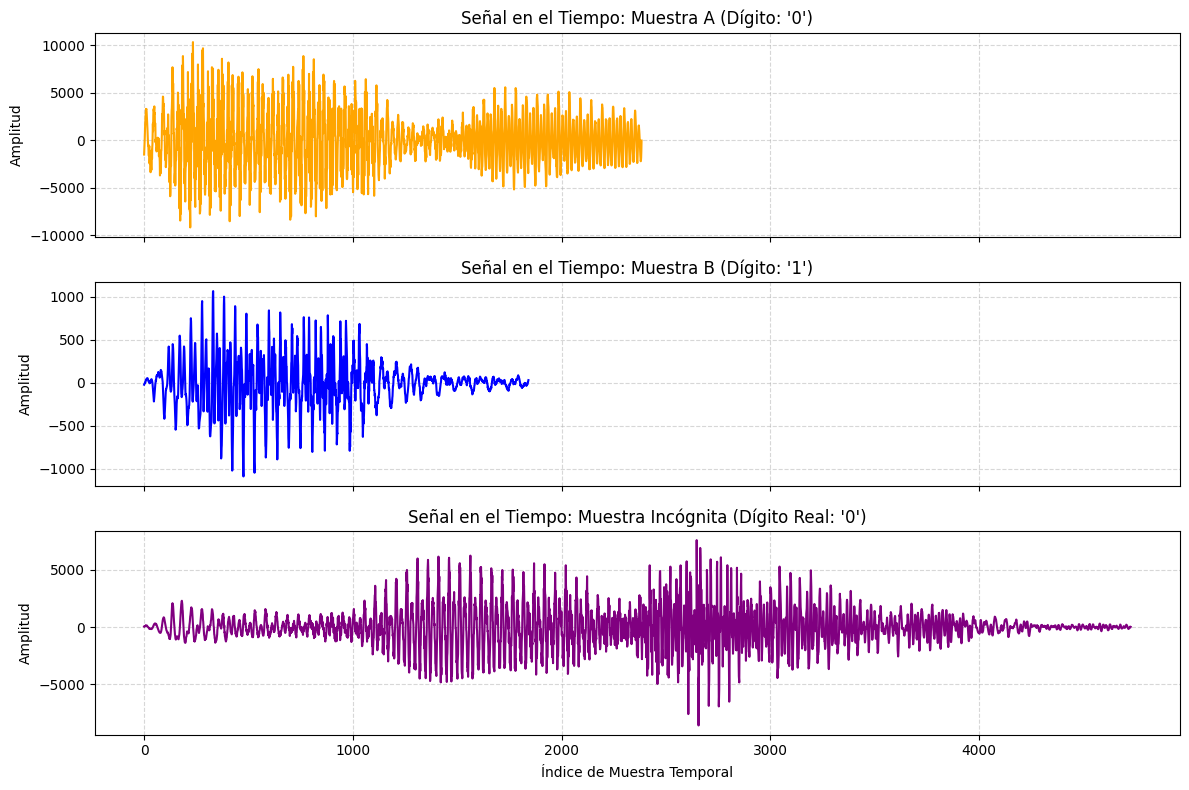

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

ax[0].plot(audio_A, color='orange')
ax[0].set_title(f"Señal en el Tiempo: Muestra A (Dígito: '{metadata_A['text'][0]}')")
ax[0].set_ylabel("Amplitud")
ax[0].grid(True, linestyle='--', alpha=0.5)

ax[1].plot(audio_B, color='blue')
ax[1].set_title(f"Señal en el Tiempo: Muestra B (Dígito: '{metadata_B['text'][0]}')")
ax[1].set_ylabel("Amplitud")
ax[1].grid(True, linestyle='--', alpha=0.5)

ax[2].plot(audio_test, color='purple')
ax[2].set_title(f"Señal en el Tiempo: Muestra Incógnita (Dígito Real: '{metadata_test['text'][0]}')")
ax[2].set_xlabel("Índice de Muestra Temporal")
ax[2].set_ylabel("Amplitud")
ax[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- Descomposición Wavelet y Gráfica de Coeficientes

In [5]:
# 1. Normalizar amplitudes al rango [-1, 1] para eliminar el efecto del volumen
a_A_norm = audio_A / np.max(np.abs(audio_A))
a_B_norm = audio_B / np.max(np.abs(audio_B))
a_test_norm = audio_test / np.max(np.abs(audio_test))

# 2. Descomposición Wavelet sobre las señales normalizadas (Nivel 4, db1)
coeffs_A = pywt.wavedec(a_A_norm, 'db1', level=4)
coeffs_B = pywt.wavedec(a_B_norm, 'db1', level=4)
coeffs_test = pywt.wavedec(a_test_norm, 'db1', level=4)

# Tomamos la aproximación (coeffs[0])
detalle_A = coeffs_A[0]
detalle_B = coeffs_B[0]
detalle_test = coeffs_test[0]

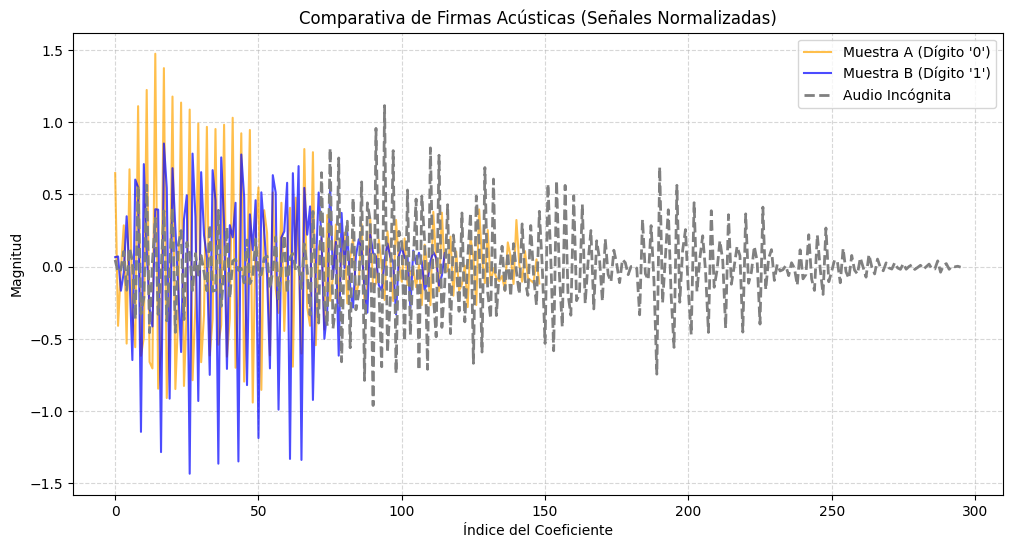

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(detalle_A, label=f"Muestra A (Dígito '{metadata_A['text'][0]}')", alpha=0.7, color='orange')
plt.plot(detalle_B, label=f"Muestra B (Dígito '{metadata_B['text'][0]}')", alpha=0.7, color='blue')
plt.plot(detalle_test, label="Audio Incógnita", linestyle='--', color='gray', linewidth=2)

plt.title("Comparativa de Firmas Acústicas (Señales Normalizadas)")
plt.xlabel("Índice del Coeficiente")
plt.ylabel("Magnitud")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

- Distancia Dinámica por DTW

In [7]:
res_A = dtw(detalle_test, detalle_A, keep_internals=True)
res_B = dtw(detalle_test, detalle_B, keep_internals=True)

print("--- RESULTADOS DE DISTANCIA DINÁMICA ---")
print(f"Distancia acumulada hacia Muestra A ('{metadata_A['text'][0]}'): {res_A.distance:.4f}")
print(f"Distancia acumulada hacia Muestra B ('{metadata_B['text'][0]}'): {res_B.distance:.4f}")

--- RESULTADOS DE DISTANCIA DINÁMICA ---
Distancia acumulada hacia Muestra A ('0'): 70.7006
Distancia acumulada hacia Muestra B ('1'): 75.4533


- Clasificación y Gráficas de Control (Twoway & Threeway)

DECISIÓN DEL CLASIFICADOR (VECINO MÁS CERCANO):
El clasificador determina que el audio se parece más a la Muestra A.
Predicción del Modelo: Es el dígito '0'
Validación Real: El dígito real era '0'

Gráfica 1: Alineación Temporal Cruzada (Twoway Mapping)


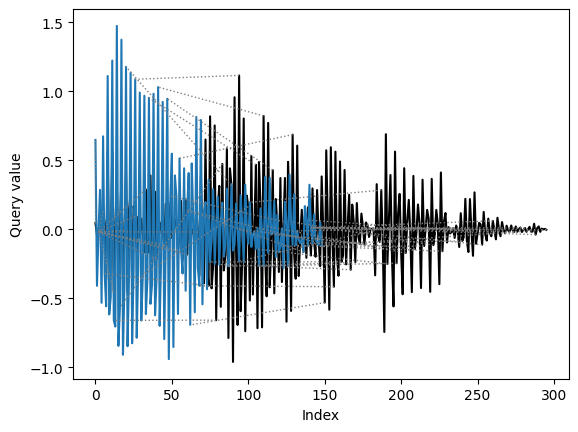


Gráfica 2: Ruta Óptima en Matriz de Costo Acumulado (Threeway)


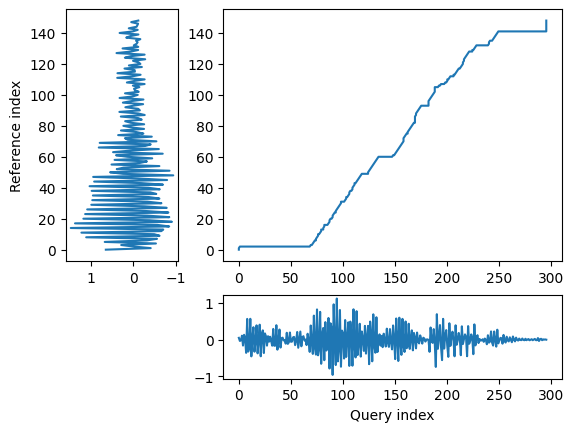

In [8]:
print("DECISIÓN DEL CLASIFICADOR (VECINO MÁS CERCANO):")

if res_A.distance < res_B.distance:
    dito_predicho = metadata_A['text'][0]
    res_ganador = res_A
    print("El clasificador determina que el audio se parece más a la Muestra A.")
else:
    dito_predicho = metadata_B['text'][0]
    res_ganador = res_B
    print("El clasificador determina que el audio se parece más a la Muestra B.")

print(f"Predicción del Modelo: Es el dígito '{dito_predicho}'")
print(f"Validación Real: El dígito real era '{metadata_test['text'][0]}'\n")

# Gráficas de control
print("Gráfica 1: Alineación Temporal Cruzada (Twoway Mapping)")
res_ganador.plot(type="twoway")
plt.show()

print("\nGráfica 2: Ruta Óptima en Matriz de Costo Acumulado (Threeway)")
res_ganador.plot(type="threeway")
plt.show()